### Ingestor Assessment - Evaluation of Run Data for January 4-10, 2026
Read pre-filled run data for January 4-10, 2026 and compute the ingestor percentage and latency KPIs.

In [13]:
from pathlib import Path
import pandas as pd

csv_path = Path('../data/ingestor_runs_2026-01-04_to_2026-01-10.csv')
df = pd.read_csv(csv_path)
df['run_started_at_utc'] = pd.to_datetime(df['run_started_at_utc'], utc=True)

window_start = pd.Timestamp('2026-01-04T00:00:00Z')
window_end = pd.Timestamp('2026-01-11T00:00:00Z')
window = df[(df['run_started_at_utc'] >= window_start) & (df['run_started_at_utc'] < window_end)].copy()

expected_hourly_runs = 7 * 24
observed_runs = len(window)
coverage_pct = (observed_runs / expected_hourly_runs) * 100 if expected_hourly_runs else 0

attempts = (window['events_published_success'] + window['publish_failures']).sum()
successes = window['events_published_success'].sum()
weighted_success_pct = (successes / attempts) * 100 if attempts else 0

summary = pd.DataFrame([
    {
        'window_start_utc': '2026-01-04',
        'window_days': 7,
        'runs_observed': observed_runs,
        'runs_expected_hourly': expected_hourly_runs,
        'coverage_pct': round(coverage_pct, 2),
        'avg_run_success_rate_pct': round(window['run_success_rate_pct'].mean(), 2),
        'weighted_success_rate_pct': round(weighted_success_pct, 2),
        'median_latency_seconds': round(window['run_latency_seconds'].median(), 1),
        'p95_latency_seconds': round(window['run_latency_seconds'].quantile(0.95), 1),
        'lt_3min_pct': round((window['run_latency_seconds'] < 180).mean() * 100, 2),
        'between_4_and_5min_pct': round(((window['run_latency_seconds'] >= 240) & (window['run_latency_seconds'] <= 300)).mean() * 100, 2),
        'gt_5min_count': int((window['run_latency_seconds'] > 300).sum())
    }
])
summary

,window_start_utc,window_days,runs_observed,runs_expected_hourly,coverage_pct,avg_run_success_rate_pct,weighted_success_rate_pct,median_latency_seconds,p95_latency_seconds,lt_3min_pct,between_4_and_5min_pct,gt_5min_count
0,2026-01-04,7,168,168,100.0,97.61,97.62,160.0,280.0,81.55,18.45,0


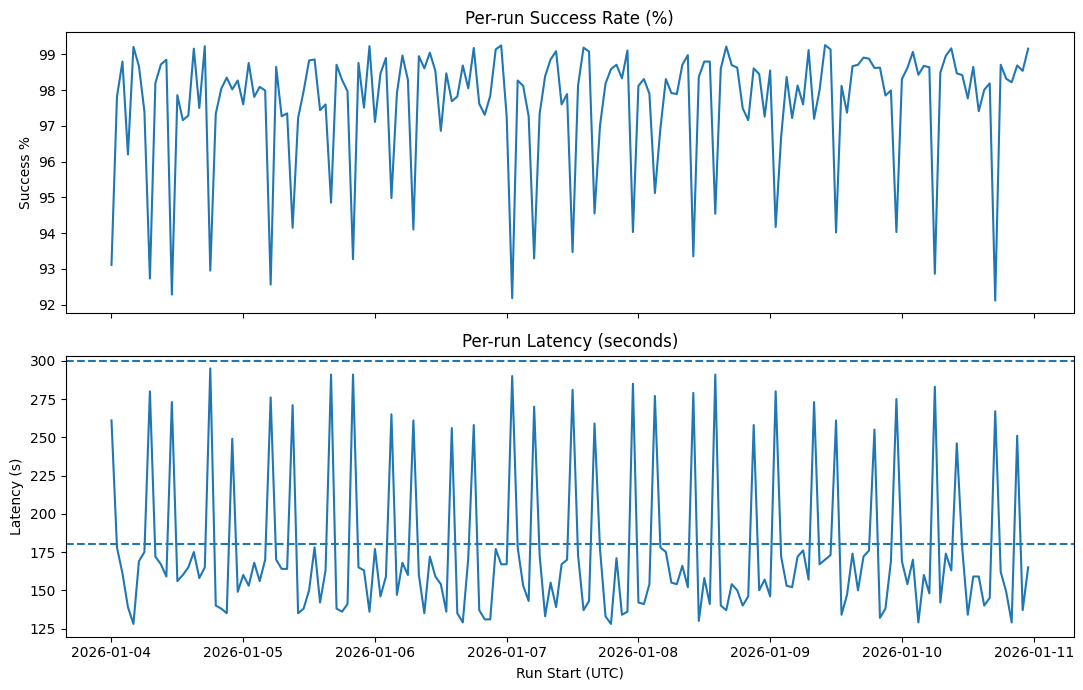

In [14]:
import matplotlib.pyplot as plt

plot_df = window.sort_values('run_started_at_utc').copy()

fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
axes[0].plot(plot_df['run_started_at_utc'], plot_df['run_success_rate_pct'])
axes[0].set_title('Per-run Success Rate (%)')
axes[0].set_ylabel('Success %')

axes[1].plot(plot_df['run_started_at_utc'], plot_df['run_latency_seconds'])
axes[1].axhline(180, linestyle='--')
axes[1].axhline(300, linestyle='--')
axes[1].set_title('Per-run Latency (seconds)')
axes[1].set_ylabel('Latency (s)')
axes[1].set_xlabel('Run Start (UTC)')

plt.tight_layout()
plt.show()